In [2]:
import os
import random
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna

from tqdm.notebook import tqdm


Зафиксировать рандом сид для воспроизведения результатов

In [3]:
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['DL_ITMO_hash_seed'] = str(seed)
    print(f'Random seed set as {seed}')

set_seed(42)

Random seed set as 42


Стандартное разбиение данных с их стандартизацией, размер батча выбран 32 +- для 6000/2000/2000 объектов в выборке приемлемо

In [4]:
df = pd.read_csv('cybersequrity.csv')
print(df.info())

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()



class CybSecDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CybSecDataset(X_train_scaled, y_train_np)
val_dataset = CybSecDataset(X_val_scaled, y_val_np)
test_dataset = CybSecDataset(X_test_scaled, y_test_np)

batch_size = 32 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   svcscan.fs_drivers                      10000 non-null  int64  
 1   callbacks.ngeneric                      10000 non-null  int64  
 2   psxview.not_in_eprocess_pool_false_avg  10000 non-null  float64
 3   psxview.not_in_eprocess_pool            10000 non-null  int64  
 4   callbacks.nanonymous                    10000 non-null  int64  
 5   psxview.not_in_session                  10000 non-null  int64  
 6   psxview.not_in_pslist                   10000 non-null  int64  
 7   psxview.not_in_pspcid_list              10000 non-null  int64  
 8   psxview.not_in_ethread_pool             10000 non-null  int64  
 9   psxview.not_in_csrss_handles            10000 non-null  int64  
 10  psxview.not_in_pslist_false_avg         10000 non-null  flo

В качестве бейзлайн модели - 2 скрытых слоя с 128 и 64 нейронами соотвественно, функция активации "стандартная" ReLu

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1) # Первый скрытый слой
        self.fc2 = nn.Linear(hidden_size1, hidden_size2) # Второй скрытый слой
        self.fc3 = nn.Linear(hidden_size2, 1) # Выходной слой
        self.activation = nn.ReLU()
    
    def forward(self, x):
        out = self.activation(self.fc1(x))
        out = self.activation(self.fc2(out))
        out = torch.sigmoid(self.fc3(out))
        return out


input_size = X_train_scaled.shape[1] # количество признаков
hidden_size1 = 128 # Количество нейронов в первом скрытом слое
hidden_size2 = 64 # Количество нейронов во втором скрытом слое

model = MLP(input_size, hidden_size1, hidden_size2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)
print(f"Модель использует: {device}")

MLP(
  (fc1): Linear(in_features=15, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (activation): ReLU()
)
Модель использует: cpu


Adam optimizer считается одним из лучших благодаря ряду преимуществ:
Adam "адаптирует" скорость обучения для каждого параметра на основе первого и второго моментов градиентов. Это позволяет автоматически регулировать размер шага для каждого параметра, что подходит для разреженных и зашумлённых данных. Adam часто приводит к более быстрой сходимости и лучшей производительности, чем другие алгоритмы оптимизации.

Эпоха 1/100, Train Loss: 0.6593, Val Loss: 0.6391
Эпоха 2/100, Train Loss: 0.6155, Val Loss: 0.6131
Эпоха 3/100, Train Loss: 0.5676, Val Loss: 0.5502
Эпоха 4/100, Train Loss: 0.5320, Val Loss: 0.5047
Эпоха 5/100, Train Loss: 0.5061, Val Loss: 0.5081
Эпоха 6/100, Train Loss: 0.4903, Val Loss: 0.4748
Эпоха 7/100, Train Loss: 0.4849, Val Loss: 0.4849
Эпоха 8/100, Train Loss: 0.4743, Val Loss: 0.4644
Эпоха 9/100, Train Loss: 0.4674, Val Loss: 0.4694
Эпоха 10/100, Train Loss: 0.4660, Val Loss: 0.4659
Эпоха 11/100, Train Loss: 0.4589, Val Loss: 0.4814
Эпоха 12/100, Train Loss: 0.4563, Val Loss: 0.4558
Эпоха 13/100, Train Loss: 0.4571, Val Loss: 0.4500
Эпоха 14/100, Train Loss: 0.4465, Val Loss: 0.4446
Эпоха 15/100, Train Loss: 0.4459, Val Loss: 0.4435
Эпоха 16/100, Train Loss: 0.4418, Val Loss: 0.4436
Эпоха 17/100, Train Loss: 0.4394, Val Loss: 0.4485
Эпоха 18/100, Train Loss: 0.4414, Val Loss: 0.4604
Эпоха 19/100, Train Loss: 0.4355, Val Loss: 0.4326
Эпоха 20/100, Train Loss: 0.4350, Val Lo

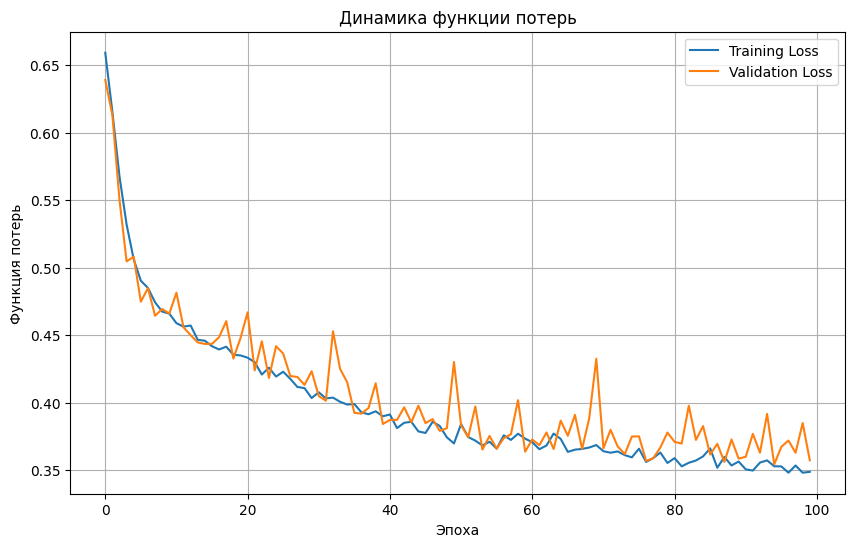

              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84       981
         1.0       0.87      0.80      0.83      1019

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [6]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()  
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Отправляем на GPU или CPU
        optimizer.zero_grad() # Обнуляем градиенты
        outputs = model(X_batch) # Прямой проход
        loss = criterion(outputs, y_batch) # Вычисляем ошибку
        loss.backward() # Обратный проход
        optimizer.step() # Обновляем веса
        train_loss += loss.item() # Собираем ошибку
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval() # Переключаем в режим валидации
    val_loss = 0.0
    with torch.no_grad(): # Отключаем градиенты
        for X_batch, y_batch in val_loader:
           X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Отправляем на GPU или CPU
           outputs = model(X_batch)
           loss = criterion(outputs, y_batch)
           val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f'Эпоха {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь')
plt.title('Динамика функции потерь')
plt.legend()
plt.grid(True)
plt.show()


model.eval()
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch) # Получаем вероятности
        predictions = (outputs > 0.5).float()  # Преобразуем вероятности в 0 или 1 с базовым порогом 0.5
        test_predictions.extend(predictions.cpu().numpy().flatten())
        test_true_labels.extend(y_batch.cpu().numpy().flatten())

print(classification_report(test_true_labels, test_predictions))

Попробовал для бейзлайн модели найти более подходящие learning rate и размеры слоев, но лучше найти гиперпараметров чтобы обучение выглядело также монотонно убывыющим и стабильным не удалось


In [9]:
import optuna
from sklearn.metrics import f1_score

# --- 1. Модель ---
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, 1)
        self.activation = nn.ReLU()
    
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

# --- 2. Функция обучения для Optuna ---
def train_model(trial):
    # Подбираем гиперпараметры
    hidden_size1 = trial.suggest_int("hidden_size1", 64, 256, step=32)
    hidden_size2 = trial.suggest_int("hidden_size2", 32, 128, step=16)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    # Создаём модель
    model = MLP(input_size, hidden_size1, hidden_size2).to(device)

    # Определяем функцию потерь и оптимизатор
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Обучение
    num_epochs = 30  # фиксированное количество эпох для Optuna
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()


    model.eval()
    val_true, val_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predictions = (outputs > 0.5).float()
            val_pred.extend(predictions.cpu().numpy().flatten())
            val_true.extend(y_batch.cpu().numpy().flatten())

    f1 = f1_score(val_true, val_pred)
    return f1


study = optuna.create_study(direction="maximize")
study.optimize(train_model, n_trials=50)

print("Best parameters:", study.best_params)

[I 2025-01-11 16:41:47,212] A new study created in memory with name: no-name-db607e21-e2ce-4fe0-a367-4a66e7fa9cd6
[I 2025-01-11 16:41:49,331] Trial 0 finished with value: 0.7965089572806615 and parameters: {'hidden_size1': 160, 'hidden_size2': 112, 'lr': 0.0006706235489722246}. Best is trial 0 with value: 0.7965089572806615.
[I 2025-01-11 16:41:51,225] Trial 1 finished with value: 0.8058203712995484 and parameters: {'hidden_size1': 96, 'hidden_size2': 128, 'lr': 0.0023884467849630132}. Best is trial 1 with value: 0.8058203712995484.
[I 2025-01-11 16:41:53,130] Trial 2 finished with value: 0.8143589743589743 and parameters: {'hidden_size1': 192, 'hidden_size2': 48, 'lr': 0.0062370305372575615}. Best is trial 2 with value: 0.8143589743589743.
[I 2025-01-11 16:41:55,159] Trial 3 finished with value: 0.7960591133004926 and parameters: {'hidden_size1': 192, 'hidden_size2': 96, 'lr': 0.00033206491925375067}. Best is trial 2 with value: 0.8143589743589743.
[I 2025-01-11 16:41:57,054] Trial 4 

Best parameters: {'hidden_size1': 128, 'hidden_size2': 128, 'lr': 0.009429135000603462}


Эпоха 1/100, Train Loss: 0.6519, Val Loss: 0.6367
Эпоха 2/100, Train Loss: 0.5806, Val Loss: 0.5119
Эпоха 3/100, Train Loss: 0.5607, Val Loss: 0.5139
Эпоха 4/100, Train Loss: 0.5321, Val Loss: 0.4654
Эпоха 5/100, Train Loss: 0.5092, Val Loss: 0.4547
Эпоха 6/100, Train Loss: 0.5073, Val Loss: 0.4536
Эпоха 7/100, Train Loss: 0.4975, Val Loss: 0.4515
Эпоха 8/100, Train Loss: 0.4914, Val Loss: 0.4391
Эпоха 9/100, Train Loss: 0.4714, Val Loss: 0.4920
Эпоха 10/100, Train Loss: 0.4723, Val Loss: 0.5392
Эпоха 11/100, Train Loss: 0.5564, Val Loss: 0.4505
Эпоха 12/100, Train Loss: 0.4599, Val Loss: 0.4195
Эпоха 13/100, Train Loss: 0.4503, Val Loss: 0.4769
Эпоха 14/100, Train Loss: 0.4599, Val Loss: 0.4127
Эпоха 15/100, Train Loss: 0.4278, Val Loss: 0.4098
Эпоха 16/100, Train Loss: 0.4359, Val Loss: 0.5080
Эпоха 17/100, Train Loss: 0.4375, Val Loss: 0.4197
Эпоха 18/100, Train Loss: 0.4198, Val Loss: 0.4157
Эпоха 19/100, Train Loss: 0.4184, Val Loss: 0.4462
Эпоха 20/100, Train Loss: 0.4294, Val Lo

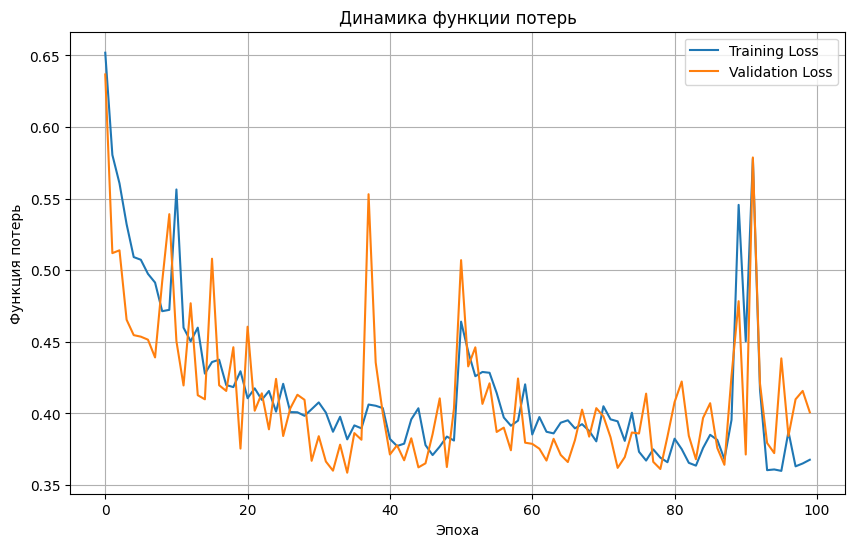

              precision    recall  f1-score   support

         0.0       0.81      0.87      0.84       981
         1.0       0.87      0.80      0.83      1019

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [10]:
best_params = study.best_params
hidden_size1 = best_params["hidden_size1"]
hidden_size2 = best_params["hidden_size2"]
lr = best_params["lr"]

model = MLP(input_size, hidden_size1, hidden_size2).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Эпоха {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

model.eval()
test_true, test_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        predictions = (outputs > 0.5).float()
        test_pred.extend(predictions.cpu().numpy().flatten())
        test_true.extend(y_batch.cpu().numpy().flatten())

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь')
plt.title('Динамика функции потерь')
plt.legend()
plt.grid(True)
plt.show()

print(classification_report(test_true, test_pred))

# Улучшение архитектуры бейзлайн модели

Увеличил размер батча до 128 (пробовал 64, 256), поменял функцию активации на ЛикиРелу, нормализацию (стабилизировать процесс обучения улучшить способность модели к обобщению, типо StandardScaler) на 2 слоя - обучение "нестабильное" скачет туда сюда, если только на 1ый слой - ошибка на валидационной выборке всегда ниже, чем на тренировочной, что тоже нехорошо. без нормализации лучше как будто для этих данных или 2 слоев.
Наличие dropout помогает сгладить углы, но не сильно, поперебирал размеры слоев, тоже добиться не получилось улучшения явного.

In [56]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, dropout_prob=0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, 1)
        self.dropout = nn.Dropout(dropout_prob)
        self.activation = nn.LeakyReLU()
    
    def forward(self, x):
        out = self.activation(self.fc1(x))
        #out = self.activation(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.activation(self.fc2(out))
        #out = self.activation(self.bn2(self.fc2(out)))                              
        out = self.dropout(out)
        out = torch.sigmoid(self.fc3(out))
        return out


input_size = X_train_scaled.shape[1] # количество признаков
hidden_size1 = 256 # Количество нейронов в первом скрытом слое
hidden_size2 = 128 # Количество нейронов во втором скрытом слое

dropout_p = 0.1

model = MLP(input_size, hidden_size1, hidden_size2,dropout_prob=dropout_p)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)
print(f"Модель использует: {device}")

MLP(
  (fc1): Linear(in_features=15, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (activation): LeakyReLU(negative_slope=0.01)
)
Модель использует: cpu


добавил scheduler - адаптивное уменьшие шага, если в течение 10 эпох не меняется, шаг уменяешься в 0.7 раз
в параметрах Adam добавил weight_decay - L2-регуляризация

/opt/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Эпоха 1/100, Train Loss: 0.6649, Val Loss: 0.6449
Эпоха 2/100, Train Loss: 0.6311, Val Loss: 0.6169
Эпоха 3/100, Train Loss: 0.6002, Val Loss: 0.5803
Эпоха 4/100, Train Loss: 0.5688, Val Loss: 0.5491
Эпоха 5/100, Train Loss: 0.5434, Val Loss: 0.5199
Эпоха 6/100, Train Loss: 0.5305, Val Loss: 0.5218
Эпоха 7/100, Train Loss: 0.5148, Val Loss: 0.4932
Эпоха 8/100, Train Loss: 0.5019, Val Loss: 0.4825
Эпоха 9/100, Train Loss: 0.4987, Val Loss: 0.4955
Эпоха 10/100, Train Loss: 0.4886, Val Loss: 0.4668
Эпоха 11/100, Train Loss: 0.4790, Val Loss: 0.4582
Эпоха 12/100, Train Loss: 0.4709, Val Loss: 0.4558
Эпоха 13/100, Train Loss: 0.4721, Val Loss: 0.4607
Эпоха 14/100, Train Loss: 0.4625, Val Loss: 0.4463
Эпоха 15/100, Train Loss: 0.4677, Val Loss: 0.4488
Эпоха 16/100, Train Loss: 0.4729, Val Loss: 0.4442
Эпоха 17/100, Train Loss: 0.4613, Val Loss: 0.4460
Эпоха 18/100, Train Loss: 0.4560, Val Loss: 0.4391
Эпоха 19/100, Train Loss: 0.4499, Val Loss: 0.4364
Эпоха 20/100, Train Loss: 0.4545, Val Lo

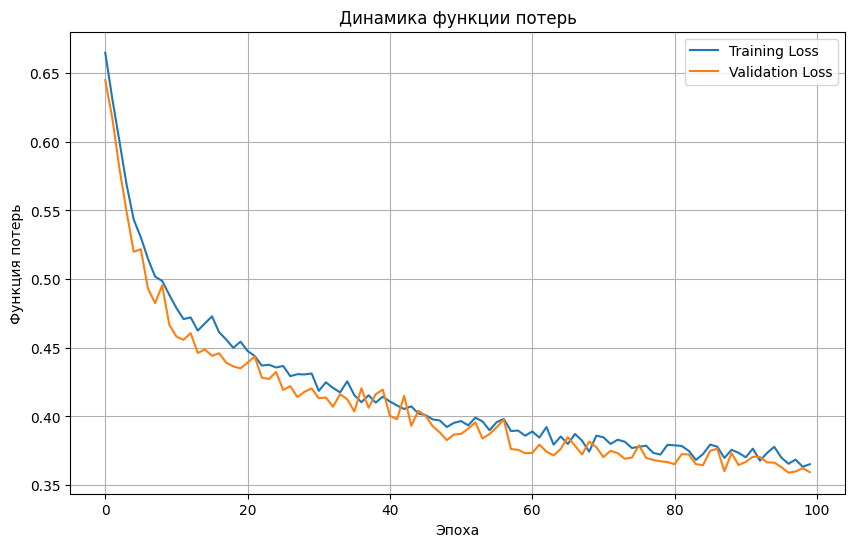

              precision    recall  f1-score   support

         0.0       0.82      0.83      0.82       981
         1.0       0.83      0.82      0.83      1019

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



In [57]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=10, verbose=True)

num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()  
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Отправляем на GPU
        optimizer.zero_grad() 
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch) 
        loss.backward() 
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
           X_batch, y_batch = X_batch.to(device), y_batch.to(device)
           outputs = model(X_batch)
           loss = criterion(outputs, y_batch)
           val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    
    print(f'Эпоха {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь')
plt.title('Динамика функции потерь')
plt.legend()
plt.grid(True)
plt.show()


model.eval()
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        predictions = (outputs > 0.5).float() 
        test_predictions.extend(predictions.cpu().numpy().flatten())
        test_true_labels.extend(y_batch.cpu().numpy().flatten())

print(classification_report(test_true_labels, test_predictions))

Еще одна попытка - добавил еще один слой, запустил optuna

In [60]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, dropout_prob=0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2])
        self.fc_out = nn.Linear(hidden_sizes[2], 1)
        self.dropout = nn.Dropout(dropout_prob)
        self.activation = nn.LeakyReLU()

    def forward(self, x):
        out = self.activation(self.fc1(x))
        # out = self.activation(self.bn1(self.fc1(out)))
        out = self.dropout(out)
        out = self.activation(self.fc2(out))
        # out = self.activation(self.bn2(self.fc2(x)))
        out = self.dropout(out)
        out = self.activation(self.fc3(out))
        # out = self.activation(self.bn3(self.fc3(out)))
        out = torch.sigmoid(self.fc_out(out))
        return out


def train_model(trial):
    hidden_size1 = trial.suggest_int("hidden_size1", 64, 256, step=32)
    hidden_size2 = trial.suggest_int("hidden_size2", 32, 128, step=16)
    hidden_size3 = trial.suggest_int("hidden_size3", 16, 64, step=16)
    dropout_prob = trial.suggest_float("dropout_prob", 0.0, 0.5, step=0.1)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    
    model = MLP(input_size, [hidden_size1, hidden_size2, hidden_size3], dropout_prob).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    num_epochs = 30
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    val_true, val_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predictions = (outputs > 0.5).float()
            val_pred.extend(predictions.cpu().numpy().flatten())
            val_true.extend(y_batch.cpu().numpy().flatten())

    f1 = f1_score(val_true, val_pred)
    return f1

study = optuna.create_study(direction="maximize")
study.optimize(train_model, n_trials=50)

print("Best parameters:", study.best_params)

best_params = study.best_params
hidden_size1 = best_params["hidden_size1"]
hidden_size2 = best_params["hidden_size2"]
hidden_size3 = best_params["hidden_size3"]
dropout_prob = best_params["dropout_prob"]
lr = best_params["lr"]
weight_decay = best_params["weight_decay"]

model = MLP(input_size, [hidden_size1, hidden_size2, hidden_size3], dropout_prob).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Эпоха {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

model.eval()
test_true, test_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        predictions = (outputs > 0.5).float()
        test_pred.extend(predictions.cpu().numpy().flatten())
        test_true.extend(y_batch.cpu().numpy().flatten())

print(classification_report(test_true, test_pred))


[I 2025-01-11 17:20:19,137] A new study created in memory with name: no-name-722185f1-1e8b-4ee7-93fa-eaf42feee2f1
[I 2025-01-11 17:20:20,128] Trial 0 finished with value: 0.8204365079365079 and parameters: {'hidden_size1': 192, 'hidden_size2': 112, 'hidden_size3': 48, 'dropout_prob': 0.0, 'lr': 0.0008110764122977196, 'weight_decay': 0.00016142434472794535}. Best is trial 0 with value: 0.8204365079365079.
[I 2025-01-11 17:20:21,378] Trial 1 finished with value: 0.7944015444015444 and parameters: {'hidden_size1': 256, 'hidden_size2': 32, 'hidden_size3': 32, 'dropout_prob': 0.1, 'lr': 0.009416582975412117, 'weight_decay': 6.48896378497079e-06}. Best is trial 0 with value: 0.8204365079365079.
[I 2025-01-11 17:20:22,594] Trial 2 finished with value: 0.7680387409200968 and parameters: {'hidden_size1': 224, 'hidden_size2': 32, 'hidden_size3': 64, 'dropout_prob': 0.1, 'lr': 0.00017682644162315955, 'weight_decay': 1.0331135990608492e-05}. Best is trial 0 with value: 0.8204365079365079.
[I 2025-

Best parameters: {'hidden_size1': 64, 'hidden_size2': 112, 'hidden_size3': 64, 'dropout_prob': 0.1, 'lr': 0.003826552381783311, 'weight_decay': 3.022972007828795e-05}
Эпоха 1/100, Train Loss: 0.6644, Val Loss: 0.6481
Эпоха 2/100, Train Loss: 0.6252, Val Loss: 0.5870
Эпоха 3/100, Train Loss: 0.5680, Val Loss: 0.5207
Эпоха 4/100, Train Loss: 0.5397, Val Loss: 0.4899
Эпоха 5/100, Train Loss: 0.5033, Val Loss: 0.4701
Эпоха 6/100, Train Loss: 0.5077, Val Loss: 0.4942
Эпоха 7/100, Train Loss: 0.4910, Val Loss: 0.4565
Эпоха 8/100, Train Loss: 0.4757, Val Loss: 0.4685
Эпоха 9/100, Train Loss: 0.4608, Val Loss: 0.4501
Эпоха 10/100, Train Loss: 0.4543, Val Loss: 0.4448
Эпоха 11/100, Train Loss: 0.4509, Val Loss: 0.4344
Эпоха 12/100, Train Loss: 0.4443, Val Loss: 0.4473
Эпоха 13/100, Train Loss: 0.4425, Val Loss: 0.4229
Эпоха 14/100, Train Loss: 0.4267, Val Loss: 0.4030
Эпоха 15/100, Train Loss: 0.4275, Val Loss: 0.4004
Эпоха 16/100, Train Loss: 0.4280, Val Loss: 0.3964
Эпоха 17/100, Train Loss: 

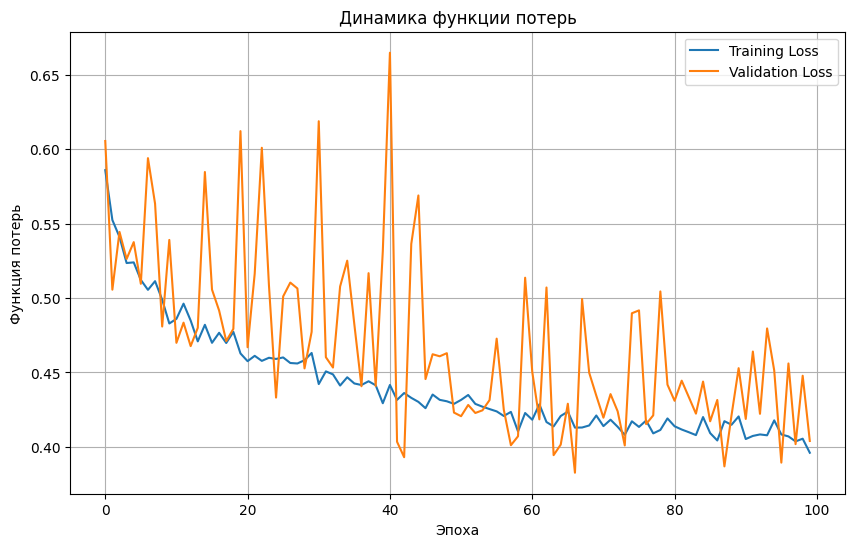

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь')
plt.title('Динамика функции потерь')
plt.legend()
plt.grid(True)
plt.show()